In [1]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
import os
import tensorflow as tf

2026-03-27 14:30:49.849071: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774647049.864680  115763 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774647049.869964  115763 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774647049.884215  115763 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774647049.884229  115763 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774647049.884231  115763 computation_placer.cc:177] computation placer alr

In [2]:
def D_JS(p1,p2,tol=1e-16):
    p1=p1/np.sum(p1)
    p2=p2/np.sum(p2)
    pm = (p1+p2)/2
    p1_nonzero = np.abs(p1)>tol
    p2_nonzero = np.abs(p2)>tol
    p1  = np.abs(p1[p1_nonzero])
    pm1 = np.abs(pm[p1_nonzero])
    p2  = np.abs(p2[p2_nonzero])
    pm2 = np.abs(pm[p2_nonzero])
    d = .5*( (p1*np.log(p1/pm1)).sum() + (p2*np.log(p2/pm2)).sum() )
    d /= np.log(2) # normalize to max of 1
    return d

In [3]:
#Transform density
def transform(density,density_ref,transform_type):
    dens = density
    dref  = density_ref
    ttype = transform_type
    if ttype=='value':
        dtrans = density
    elif ttype=='sqrt':
        dtrans = np.sqrt(np.abs(density))
    elif ttype=='log':
        dtrans  = np.log(np.abs(density))
    elif ttype=='residual_noise':
        dval  = dref
        dsqrt = np.sqrt(np.abs(dref))
        dtrans = (dens-dval)/dsqrt
    else:
        raise RuntimeError('bad transform type')
    return dtrans


def inverse_transform(density_trans,density_ref,transform_type):
    dref   = density_ref
    ttype  = transform_type
    dtrans = density_trans
    if ttype=='value':
        density = dtrans
    elif ttype=='sqrt':
        density = dtrans**2
    elif ttype=='log':
        density = np.log(np.abs(dtrans))
    elif ttype=='residual_noise':
        dval  = dref
        dsqrt = np.sqrt(np.abs(dref))
        density = dval + dsqrt*dtrans
    else:
        raise RuntimeError('bad transform type')
    return density


VMC Ref shape: (140, 84, 112)


I0000 00:00:1774647073.657962  115763 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38479 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:41:00.0, compute capability: 8.0


Found 33 files to process.
Processing File 1/33 - Samples: 110100480


I0000 00:00:1774647074.825228  115914 service.cc:152] XLA service 0x7fe8b4003720 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774647074.825258  115914 service.cc:160]   StreamExecutor device (0): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2026-03-27 14:31:14.846107: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774647074.916698  115914 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1774647077.339037  115914 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Processing File 2/33 - Samples: 143360
Processing File 3/33 - Samples: 430080
Processing File 4/33 - Samples: 35840
Processing File 5/33 - Samples: 4587520
Processing File 6/33 - Samples: 165150720
Processing File 7/33 - Samples: 9175040
Processing File 8/33 - Samples: 573440
Processing File 9/33 - Samples: 36700160
Processing File 10/33 - Samples: 2642411520
Processing File 11/33 - Samples: 440401920
Processing File 12/33 - Samples: 5160960
Processing File 13/33 - Samples: 5284823040
Processing File 14/33 - Samples: 1146880
Processing File 15/33 - Samples: 330301440
Processing File 16/33 - Samples: 2293760
Processing File 17/33 - Samples: 860160
Processing File 18/33 - Samples: 27525120
Processing File 19/33 - Samples: 71680
Processing File 20/33 - Samples: 286720
Processing File 21/33 - Samples: 1321205760
Processing File 22/33 - Samples: 1720320
Processing File 23/33 - Samples: 13762560
Processing File 24/33 - Samples: 55050240
Processing File 25/33 - Samples: 41287680
Processing Fi

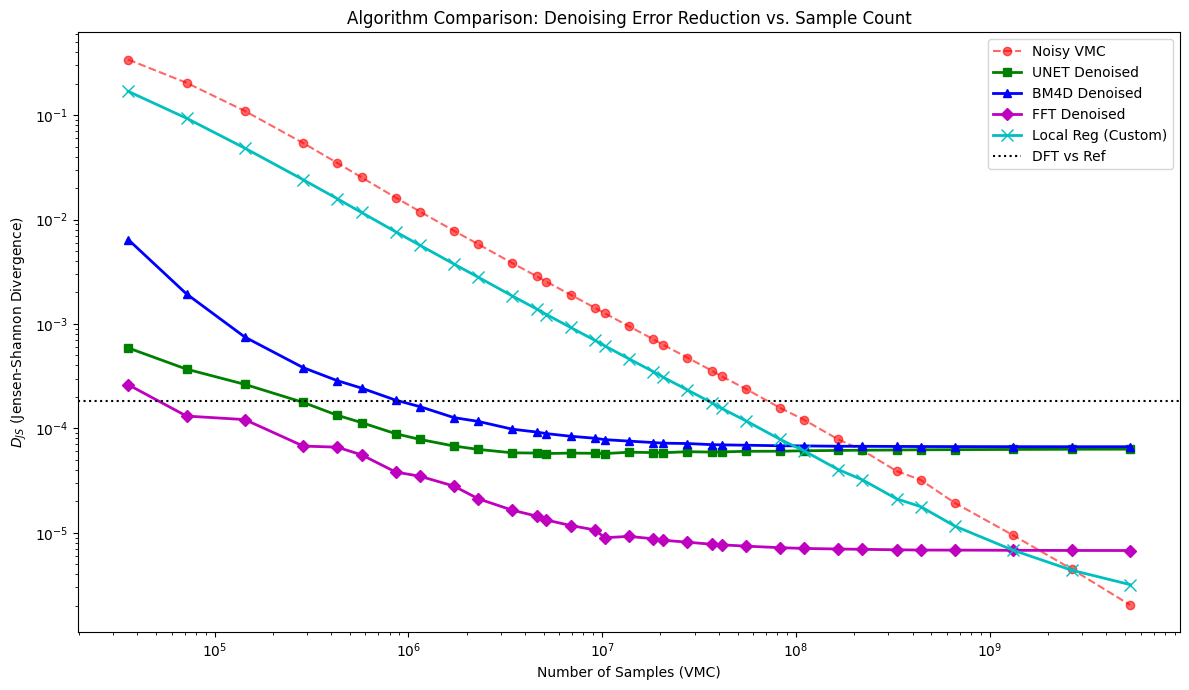

In [4]:
import os
import sys
import glob
import re
import logging  # <-- Added to handle the debug spam
import h5py
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from bm4d import bm4d

# --- Suppress Matplotlib Debug Output ---
logging.getLogger('matplotlib').setLevel(logging.WARNING)
logging.getLogger('matplotlib.ticker').setLevel(logging.WARNING)

# --- Path Setups (Adjust as needed) ---
qmc_algo_path = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/qmc_algo_tools') 
dev = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/developer_tools') 
sys.path.insert(0, qmc_algo_path) 
sys.path.insert(0, dev) 
from qmc_algo_tools.density_denoise import DensityFourierFilterErrorCeil

# Make sure D_JS is imported properly here
# from your_utils import D_JS

# --- Definitions ---
def local_polyfit(y, deg=1, window=3):
    """Local polynomial regression method"""
    N = len(y)
    half = window // 2
    x = np.arange(N)
    y_out = np.zeros(N)

    for i in range(N):
        start = max(0, i - half)
        end   = min(N, i + half + 1)

        # local coordinates
        xi = x[start:end]
        yi = y[start:end]

        # fit polynomial to window
        coeffs = np.polyfit(xi, yi, deg)

        # predict at point i
        y_out[i] = np.polyval(coeffs, x[i])
    return y_out

# --- Transformation Functions (Needed for UNET) ---
def transform(density, density_ref, transform_type):
    if transform_type == 'residual_noise':
        return (density - density_ref) / np.sqrt(np.abs(density_ref))
    raise RuntimeError('bad transform type')

def inverse_transform(density_trans, density_ref, transform_type):
    if transform_type == 'residual_noise':
        return density_ref + np.sqrt(np.abs(density_ref)) * density_trans
    raise RuntimeError('bad transform type')

# --- 1. Load Reference Data ---
# VMC Reference
vmc_ref_path = '/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_J2/density_tot_ref_mean.h5'
with h5py.File(vmc_ref_path, 'r') as file:
    ref_d = file['density'][:]
print(f"VMC Ref shape: {ref_d.shape}")

# DFT Data
dft_path = '/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_noJ/density_tot_ref.h5'
with h5py.File(dft_path, 'r') as file:
    dft_d = file['density'][:]


# --- 2. Setup Models and Directories ---
unet_model = tf.keras.models.load_model('/pscratch/sd/k/kberard/SCGSR/EDDA/BP/Density_Model/U-NET/residual_denoiser_40M_Blob_NODFT.keras')

data_dir = '/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_J2'
file_pattern = os.path.join(data_dir, "density_tot_vmc_mean_*.h5")
files = glob.glob(file_pattern)

results = []
trans_type = 'residual_noise'

# Initialize FFT class ONCE before the loop
dm = DensityFourierFilterErrorCeil(density_ref=dft_d, filter_mode='augment')

print(f"Found {len(files)} files to process.")

# --- 3. Processing Loop ---
counter = 0
for fpath in files:
    counter += 1
    match = re.search(r'mean_(\d+)\.h5', os.path.basename(fpath))
    if not match: continue
    sample_count = int(match.group(1))
    print(f"Processing File {counter}/{len(files)} - Samples: {sample_count}")
    
    # Calculate Dynamic Sigma based on our calibration
    sigma_psd = 0.000001 * np.sqrt(6881280 / sample_count)
    
    with h5py.File(fpath, 'r') as f:
        test_d = np.array(f['density'])
    
    # ----------------------------------------------------
    # Method A: UNET (Uses residual transform)
    # ----------------------------------------------------
    input_reshaped = test_d[np.newaxis, ..., np.newaxis]
    dft_reshaped   = dft_d[np.newaxis, ..., np.newaxis]
    input_residual = transform(input_reshaped, dft_reshaped, trans_type)
    
    pred_residual = unet_model.predict(input_residual, verbose=0)
    denoised_raw = inverse_transform(pred_residual, dft_reshaped, trans_type)
    denoised_unet = np.maximum(denoised_raw[0, ..., 0], 0.0)

    # ----------------------------------------------------
    # Method B: BM4D (Raw Density + Positive Clamp)
    # ----------------------------------------------------
    bm4d_raw = bm4d(test_d, sigma_psd)
    denoised_bm4d = np.maximum(bm4d_raw, 0.0)
    
    # ----------------------------------------------------
    # Method C: FFT (Raw Density)
    # ----------------------------------------------------
    denoised_fft = dm.denoise(test_d)

    # ----------------------------------------------------
    # Method D: Local Regression (Custom Function)
    # ----------------------------------------------------
    x_flat = test_d.ravel()
    
    y_smooth_lr = local_polyfit(x_flat, deg=2, window=5)
    lr_raw_3d = y_smooth_lr.reshape(test_d.shape) 
    denoised_lr = np.maximum(lr_raw_3d, 0.0)

    # ----------------------------------------------------
    # Calculate and Store Metrics
    # ----------------------------------------------------
    jsd_noisy  = D_JS(test_d, ref_d)
    jsd_unet   = D_JS(denoised_unet, ref_d)
    jsd_bm4d   = D_JS(denoised_bm4d, ref_d)
    jsd_fft    = D_JS(denoised_fft, ref_d)
    jsd_lr     = D_JS(denoised_lr, ref_d)
    
    results.append((sample_count, jsd_noisy, jsd_unet, jsd_bm4d, jsd_fft, jsd_lr))


# --- 4. Sorting & Plotting ---
results.sort(key=lambda x: x[0])
samples, jsd_noisy, jsd_unet, jsd_bm4d, jsd_fft, jsd_lr = zip(*results)

DFT_vs_DMC = D_JS(ref_d, dft_d)

plt.figure(figsize=(12, 7))

# Plot all performance curves
plt.plot(samples, jsd_noisy,  'r--o', label='Noisy VMC', alpha=0.6)
plt.plot(samples, jsd_unet,   'g-s',  label='UNET Denoised', linewidth=2)
plt.plot(samples, jsd_bm4d,   'b-^',  label='BM4D Denoised', linewidth=2)
plt.plot(samples, jsd_fft,    'm-D',  label='FFT Denoised', linewidth=2)
plt.plot(samples, jsd_lr,     'c-x',  label='Local Reg (Custom)', linewidth=2, markersize=8)

# Graph Formatting
plt.xscale('log')
plt.yscale('log')
plt.axhline(DFT_vs_DMC, color="black", linestyle=":", label="DFT vs Ref")

plt.xlabel('Number of Samples (VMC)')
plt.ylabel('$D_{JS}$ (Jensen-Shannon Divergence)')
plt.title('Algorithm Comparison: Denoising Error Reduction vs. Sample Count')
plt.legend()

# Turn off the gridmarks completely
plt.grid(False)

plt.tight_layout()
plt.show()

2026-05-15 07:37:59.231976: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778855879.579052  181147 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778855879.637120  181147 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778855880.341125  181147 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778855880.341146  181147 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778855880.341149  181147 computation_placer.cc:177] computation placer alr

/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_J2/density_tot_vmc_mean_0110100480.h5


I0000 00:00:1778855994.456095  181606 service.cc:152] XLA service 0x7fb7e004d550 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778855994.456121  181606 service.cc:160]   StreamExecutor device (0): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
I0000 00:00:1778855994.456124  181606 service.cc:160]   StreamExecutor device (1): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
I0000 00:00:1778855994.456126  181606 service.cc:160]   StreamExecutor device (2): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
I0000 00:00:1778855994.456128  181606 service.cc:160]   StreamExecutor device (3): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2026-05-15 07:39:54.475676: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778855994.595798  181606 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1778855998.594188  181606 device_com

/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_J2/density_tot_vmc_mean_0000143360.h5
/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_J2/density_tot_vmc_mean_0000430080.h5
/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_J2/density_tot_vmc_mean_0000035840.h5
/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_J2/density_tot_vmc_mean_0004587520.h5
/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_J2/density_tot_vmc_mean_0165150720.h5
/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_J2/density_tot_vmc_mean_0009175040.h5
/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_J2/density_tot_vmc_mean_0000573440.h5
/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_J2/density_tot_vmc_mean_0036700160.h5
/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_J2/density_tot_vmc_mean_2642411520.h5
/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vm

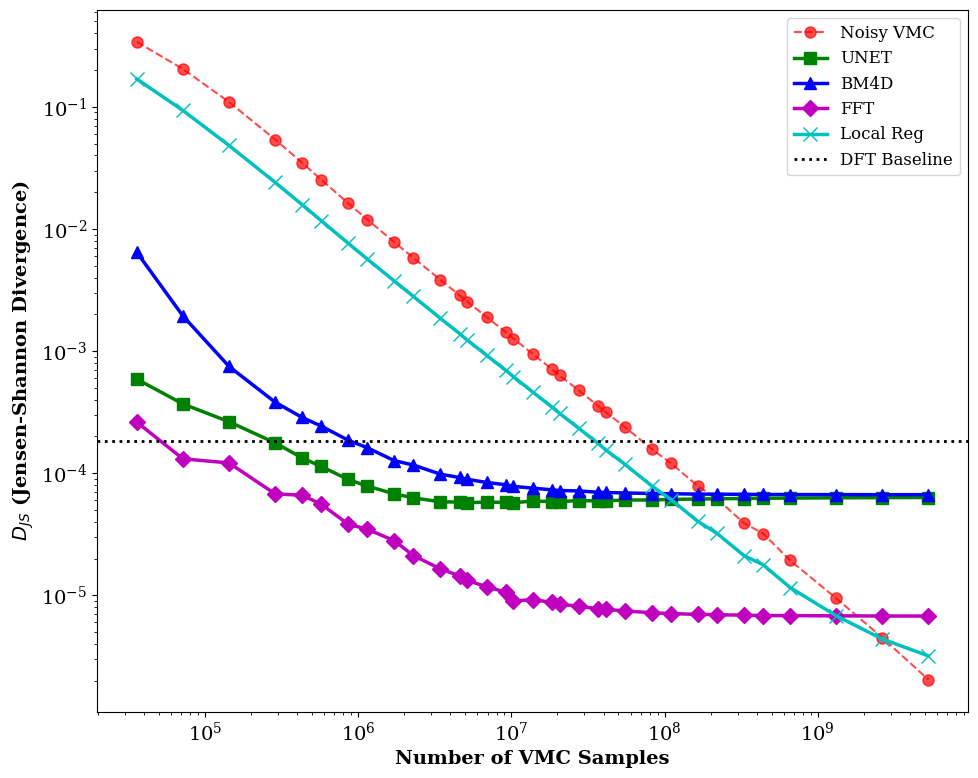

In [1]:
import os
import sys
import glob
import re
import logging
import h5py
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd  # Added for CSV handling
from bm4d import bm4d

# --- Suppress Matplotlib Debug Output ---
logging.getLogger('matplotlib').setLevel(logging.WARNING)
logging.getLogger('matplotlib.ticker').setLevel(logging.WARNING)

# --- Path Setups ---
qmc_algo_path = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/qmc_algo_tools') 
dev = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/developer_tools') 
sys.path.insert(0, qmc_algo_path) 
sys.path.insert(0, dev) 
from qmc_algo_tools.density_denoise import DensityFourierFilterErrorCeil

# NOTE: Ensure D_JS is defined in your environment or imported
def D_JS(p1, p2, tol=1e-16):
    p1 = p1 / np.sum(p1)
    p2 = p2 / np.sum(p2)
    pm = (p1 + p2) / 2
    p1_nonzero = np.abs(p1) > tol
    p2_nonzero = np.abs(p2) > tol
    p1  = np.abs(p1[p1_nonzero])
    pm1 = np.abs(pm[p1_nonzero])
    p2  = np.abs(p2[p2_nonzero])
    pm2 = np.abs(pm[p2_nonzero])
    d = .5 * ( (p1 * np.log(p1 / pm1)).sum() + (p2 * np.log(p2 / pm2)).sum() )
    d /= np.log(2)
    return d

def local_polyfit(y, deg=1, window=3):
    """Local polynomial regression method"""
    N = len(y)
    half = window // 2  # <--- Fixed: divided by 2, not 'half'
    x = np.arange(N)
    y_out = np.zeros(N)

    for i in range(N):
        start = max(0, i - half)
        end   = min(N, i + half + 1)

        # local coordinates
        xi = x[start:end]
        yi = y[start:end]

        # fit polynomial to window
        coeffs = np.polyfit(xi, yi, deg)

        # predict at point i
        y_out[i] = np.polyval(coeffs, x[i])
    return y_out

def transform(density, density_ref, transform_type):
    if transform_type == 'residual_noise':
        return (density - density_ref) / np.sqrt(np.abs(density_ref))
    raise RuntimeError('bad transform type')

def inverse_transform(density_trans, density_ref, transform_type):
    if transform_type == 'residual_noise':
        return density_ref + np.sqrt(np.abs(density_ref)) * density_trans
    raise RuntimeError('bad transform type')

# --- 1. Load Reference Data ---
vmc_ref_path = '/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_J2/density_tot_ref_mean.h5'
with h5py.File(vmc_ref_path, 'r') as file:
    ref_d = file['density'][:]

dft_path = '/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_noJ/density_tot_ref.h5'
with h5py.File(dft_path, 'r') as file:
    dft_d = file['density'][:]

# --- 2. Setup Models ---
unet_model = tf.keras.models.load_model('/pscratch/sd/k/kberard/SCGSR/EDDA/BP/Density_Model/U-NET/residual_denoiser_40M_Blob_NODFT.keras')
data_dir = '/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_J2'
files = glob.glob(os.path.join(data_dir, "density_tot_vmc_mean_*.h5"))
results = []
trans_type = 'residual_noise'
dm = DensityFourierFilterErrorCeil(density_ref=dft_d, filter_mode='augment')

# --- 3. Processing Loop ---
for fpath in files:
    print(fpath)
    match = re.search(r'mean_(\d+)\.h5', os.path.basename(fpath))
    if not match: continue
    sample_count = int(match.group(1))
    sigma_psd = 0.000001 * np.sqrt(6881280 / sample_count)
    
    with h5py.File(fpath, 'r') as f:
        test_d = np.array(f['density'])
    
    # UNET
    input_reshaped = test_d[np.newaxis, ..., np.newaxis]
    dft_reshaped   = dft_d[np.newaxis, ..., np.newaxis]
    input_residual = transform(input_reshaped, dft_reshaped, trans_type)
    pred_residual = unet_model.predict(input_residual, verbose=0)
    denoised_unet = np.maximum(inverse_transform(pred_residual, dft_reshaped, trans_type)[0, ..., 0], 0.0)

    # BM4D
    denoised_bm4d = np.maximum(bm4d(test_d, sigma_psd), 0.0)
    
    # FFT
    denoised_fft = dm.denoise(test_d)

    # Local Regression
    denoised_lr = np.maximum(local_polyfit(test_d.ravel(), deg=2, window=5).reshape(test_d.shape), 0.0)

    # Metrics
    results.append({
        "Samples": sample_count,
        "Noisy_VMC": D_JS(test_d, ref_d),
        "UNET": D_JS(denoised_unet, ref_d),
        "BM4D": D_JS(denoised_bm4d, ref_d),
        "FFT": D_JS(denoised_fft, ref_d),
        "Local_Reg": D_JS(denoised_lr, ref_d)
    })

# --- 4. Data Export & Plotting ---
df = pd.DataFrame(results).sort_values("Samples")
df.to_csv("denoising_performance_results.csv", index=False)
print("Results saved to denoising_performance_results.csv")

DFT_vs_DMC = D_JS(ref_d, dft_d)

# Plotting with Publication Settings
plt.rcParams.update({'font.size': 14, 'font.family': 'serif'})
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(df["Samples"], df["Noisy_VMC"], 'r--o', label='Noisy VMC', alpha=0.7, markersize=8)
ax.plot(df["Samples"], df["UNET"],      'g-s',  label='UNET', linewidth=2.5, markersize=8)
ax.plot(df["Samples"], df["BM4D"],      'b-^',  label='BM4D', linewidth=2.5, markersize=8)
ax.plot(df["Samples"], df["FFT"],       'm-D',  label='FFT', linewidth=2.5, markersize=8)
ax.plot(df["Samples"], df["Local_Reg"], 'c-x',  label='Local Reg', linewidth=2.5, markersize=10)

ax.axhline(DFT_vs_DMC, color="black", linestyle=":", label="DFT Baseline", linewidth=2)

# Log Scaling
ax.set_xscale('log')
ax.set_yscale('log')

# Labels and Legibility
ax.set_xlabel('Number of VMC Samples', fontweight='bold')
ax.set_ylabel('$D_{JS}$ (Jensen-Shannon Divergence)', fontweight='bold')
ax.legend(frameon=True, loc='best', fontsize=12)
ax.grid(False)

plt.tight_layout()

# Save for Publication
plt.savefig("denoising_comparison_pub.png", dpi=300, bbox_inches='tight')
plt.savefig("denoising_comparison_pub.pdf", bbox_inches='tight')
plt.show()

In [ ]:
print("here")

In [5]:
import csv

# ... [Previous Code] ...

# --- 4. Sorting & Plotting ---
results.sort(key=lambda x: x[0])
samples, jsd_noisy, jsd_unet, jsd_bm4d, jsd_fft, jsd_lr = zip(*results)

# ==========================================
# NEW CODE: Save to CSV
# ==========================================
csv_filename = "denoising_jsd_results.csv"

with open(csv_filename, mode='w', newline='') as file:
    writer = csv.writer(file)
    # Write the header row
    writer.writerow(['Samples', 'Noisy_VMC', 'UNET', 'BM4D', 'FFT', 'Local_Reg'])
    
    # Write the data rows
    for i in range(len(samples)):
        writer.writerow([
            samples[i], 
            jsd_noisy[i], 
            jsd_unet[i], 
            jsd_bm4d[i], 
            jsd_fft[i], 
            jsd_lr[i]
        ])

print(f"Data successfully saved to {csv_filename}!")
# ==========================================

DFT_vs_DMC = D_JS(ref_d, dft_d)
# ... [Rest of Plotting Code] ...

Data successfully saved to denoising_jsd_results.csv!
